In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import sys
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    SUBMISSIONS_DIR,
    MODELS_DIR,
    TARGET_COL,
    ID_COL,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_FIG_DIR = FIGURES_DIR / "final_report"
FINAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Final figure dir:", FINAL_FIG_DIR)

Project root: c:\Coding\Home-Credit-Default-Risk
Final figure dir: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report


In [17]:
def find_optional_existing(base_dir, candidates):
    for name in candidates:
        path = base_dir / name
        if path.exists():
            return path
    return None

def parse_metric(text, pattern):
    match = re.search(pattern, text, flags=re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

def parse_report(report_path):
    if report_path is None or not report_path.exists():
        return {
            "report_file": None,
            "mean_fold_auc": np.nan,
            "oof_auc": np.nan,
        }

    text = report_path.read_text(encoding="utf-8", errors="ignore")

    return {
        "report_file": report_path.name,
        "mean_fold_auc": parse_metric(text, r"Mean fold AUC:\s*([0-9.]+)"),
        "oof_auc": parse_metric(text, r"OOF AUC:\s*([0-9.]+)"),
    }

def to_markdown_table(df):
    cols = list(df.columns)
    lines = []
    lines.append("| " + " | ".join(cols) + " |")
    lines.append("| " + " | ".join(["---"] * len(cols)) + " |")
    for _, row in df.iterrows():
        vals = [str(row[c]) for c in cols]
        lines.append("| " + " | ".join(vals) + " |")
    return "\n".join(lines)

def clean_project_tree_text():
    return """Home-Credit-Default-Risk/
├── data/
│   ├── raw/
│   ├── processed/
│   └── sample/
├── notebooks/
│   ├── 01_data_audit.ipynb
│   ├── 02_eda_main_table.ipynb
│   ├── 03_baseline_main_table.ipynb
│   ├── 04_bureau_features.ipynb
│   ├── 05_model_with_bureau.ipynb
│   ├── 06_previous_application_features.ipynb
│   ├── 07_model_with_previous.ipynb
│   ├── 08_payment_history_features.ipynb
│   ├── 09_model_with_payments.ipynb
│   ├── 10_error_analysis.ipynb
│   └── 11_final_submission_and_report.ipynb
├── src/
│   ├── __init__.py
│   ├── config.py
│   ├── data_loader.py
│   ├── preprocessing.py
│   ├── train.py
│   ├── inference.py
│   ├── features_bureau.py
│   ├── features_previous.py
│   └── features_payments.py
├── outputs/
│   ├── figures/
│   ├── models/
│   ├── reports/
│   └── submissions/
├── README.md
├── requirements.txt
└── .gitignore"""

In [18]:
report_candidates = {
    "baseline": [
        "baseline_results.md",
    ],
    "bureau": [
        "model_v2_with_bureau.md",
    ],
    "bureau_previous": [
        "model_v3_bureau_previous.md",
    ],
    "payments": [
        "model_v4_with_payments.md",
        "full_model_results.md",
    ],
}

submission_candidates = {
    "baseline": [
        "baseline_main_table_catboost.csv",
        "baseline_main_table.csv",
    ],
    "bureau": [
        "model_v2_bureau.csv",
    ],
    "bureau_previous": [
        "model_v3_bureau_previous.csv",
    ],
    "payments": [
        "model_v4_with_payments.csv",
        "final_submission.csv",
    ],
}

report_paths = {
    name: find_optional_existing(REPORTS_DIR, candidates)
    for name, candidates in report_candidates.items()
}

submission_paths = {
    name: find_optional_existing(SUBMISSIONS_DIR, candidates)
    for name, candidates in submission_candidates.items()
}

print("Report files:")
for k, v in report_paths.items():
    print(f"{k:16} -> {v.name if v else 'NOT FOUND'}")

print("\nSubmission files:")
for k, v in submission_paths.items():
    print(f"{k:16} -> {v.name if v else 'NOT FOUND'}")

Report files:
baseline         -> baseline_results.md
bureau           -> model_v2_with_bureau.md
bureau_previous  -> model_v3_bureau_previous.md
payments         -> model_v4_with_payments.md

Submission files:
baseline         -> baseline_main_table_catboost.csv
bureau           -> model_v2_bureau.csv
bureau_previous  -> model_v3_bureau_previous.csv
payments         -> model_v4_with_payments.csv


In [19]:
comparison_rows = []

label_map = {
    "baseline": "Baseline (Main Table)",
    "bureau": "Main + Bureau",
    "bureau_previous": "Main + Bureau + Previous",
    "payments": "Main + Bureau + Previous + Payments",
}

order_map = {
    "baseline": 1,
    "bureau": 2,
    "bureau_previous": 3,
    "payments": 4,
}

fallback_scores = {
    "baseline": {"mean_fold_auc": 0.759922, "oof_auc": 0.759895},
    "bureau": {"mean_fold_auc": 0.765376, "oof_auc": 0.765354},
    "bureau_previous": {"mean_fold_auc": 0.772989, "oof_auc": 0.772974},
    "payments": {"mean_fold_auc": np.nan, "oof_auc": np.nan},
}

for key in ["baseline", "bureau", "bureau_previous", "payments"]:
    parsed = parse_report(report_paths[key])

    mean_fold_auc = parsed["mean_fold_auc"]
    oof_auc = parsed["oof_auc"]

    if pd.isna(mean_fold_auc):
        mean_fold_auc = fallback_scores[key]["mean_fold_auc"]
    if pd.isna(oof_auc):
        oof_auc = fallback_scores[key]["oof_auc"]

    comparison_rows.append({
        "order": order_map[key],
        "model_key": key,
        "model_name": label_map[key],
        "mean_fold_auc": mean_fold_auc,
        "oof_auc": oof_auc,
        "report_file": parsed["report_file"],
        "submission_file": submission_paths[key].name if submission_paths[key] else None,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("order").reset_index(drop=True)

comparison_df["lift_vs_previous"] = comparison_df["oof_auc"].diff()
comparison_df["lift_vs_baseline"] = comparison_df["oof_auc"] - comparison_df.loc[comparison_df["model_key"] == "baseline", "oof_auc"].iloc[0]

display(comparison_df)

,order,model_key,model_name,mean_fold_auc,oof_auc,report_file,submission_file,lift_vs_previous,lift_vs_baseline
0,1,baseline,Baseline (Main Table),0.759922,0.759895,baseline_results.md,baseline_main_table_catboost.csv,NaN,0.000000
1,2,bureau,Main + Bureau,0.765376,0.765354,model_v2_with_bureau.md,model_v2_bureau.csv,0.005459,0.005459
2,3,bureau_previous,Main + Bureau + Previous,0.772989,0.772974,model_v3_bureau_previous.md,model_v3_bureau_previous.csv,0.007620,0.013079
3,4,payments,Main + Bureau + Previous + Payments,0.785389,0.785274,model_v4_with_payments.md,model_v4_with_payments.csv,0.012300,0.025379


In [20]:
comparison_csv_path = REPORTS_DIR / "final_model_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

print("Saved:", comparison_csv_path)

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_model_comparison.csv


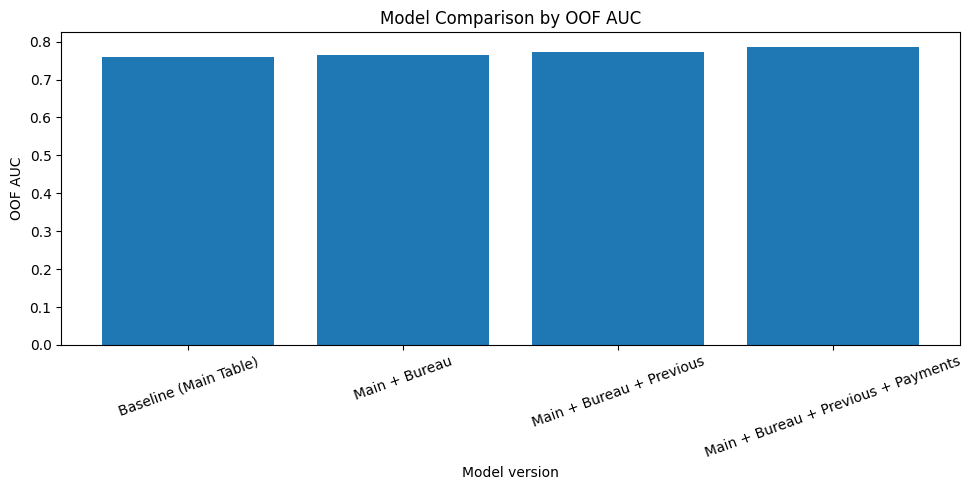

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\01_model_comparison.png


In [21]:
plot_df = comparison_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model_name"], plot_df["oof_auc"])
plt.title("Model Comparison by OOF AUC")
plt.xlabel("Model version")
plt.ylabel("OOF AUC")
plt.xticks(rotation=20)
plt.tight_layout()

comparison_fig_path = FINAL_FIG_DIR / "01_model_comparison.png"
plt.savefig(comparison_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", comparison_fig_path)

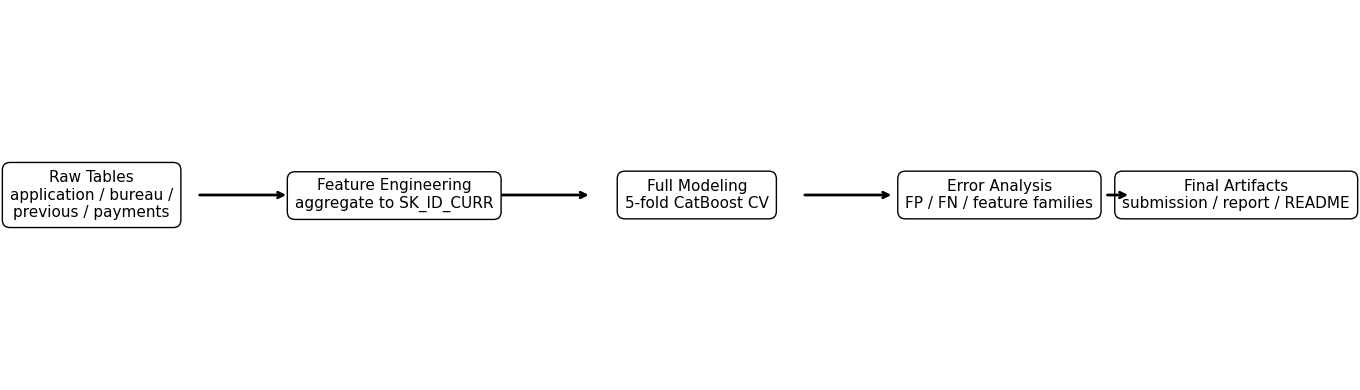

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\02_project_pipeline_overview.png


In [22]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

boxes = [
    (0.05, 0.5, "Raw Tables\napplication / bureau /\nprevious / payments"),
    (0.28, 0.5, "Feature Engineering\naggregate to SK_ID_CURR"),
    (0.51, 0.5, "Full Modeling\n5-fold CatBoost CV"),
    (0.74, 0.5, "Error Analysis\nFP / FN / feature families"),
    (0.92, 0.5, "Final Artifacts\nsubmission / report / README"),
]

for x, y, text in boxes:
    ax.text(
        x, y, text,
        ha="center", va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white")
    )

for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + 0.08
    x2 = boxes[i + 1][0] - 0.08
    ax.annotate("", xy=(x2, 0.5), xytext=(x1, 0.5),
                arrowprops=dict(arrowstyle="->", lw=2))

pipeline_fig_path = FINAL_FIG_DIR / "02_project_pipeline_overview.png"
plt.tight_layout()
plt.savefig(pipeline_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", pipeline_fig_path)

In [23]:
model_files = sorted([p.name for p in MODELS_DIR.iterdir() if p.is_file()])

print("Model files found:")
for f in model_files:
    print("-", f)

source_model_path = find_optional_existing(
    MODELS_DIR,
    [
        "final_model.joblib",
        "model_v4_with_payments_fold5.joblib",
    ],
)

final_model_path = MODELS_DIR / "final_model.joblib"

if source_model_path is not None and source_model_path.exists():
    if source_model_path.resolve() != final_model_path.resolve():
        shutil.copyfile(source_model_path, final_model_path)
    print("Final model artifact:", final_model_path)
else:
    print("No model artifact found in outputs/models yet.")
    print("Recommended: save or copy one trained model as outputs/models/final_model.joblib")

Model files found:
- model_v4_with_payments_fold5.joblib
Final model artifact: C:\Coding\Home-Credit-Default-Risk\outputs\models\final_model.joblib


In [24]:
tree_text = clean_project_tree_text()
print(tree_text)

Home-Credit-Default-Risk/
├── data/
│   ├── raw/
│   ├── processed/
│   └── sample/
├── notebooks/
│   ├── 01_data_audit.ipynb
│   ├── 02_eda_main_table.ipynb
│   ├── 03_baseline_main_table.ipynb
│   ├── 04_bureau_features.ipynb
│   ├── 05_model_with_bureau.ipynb
│   ├── 06_previous_application_features.ipynb
│   ├── 07_model_with_previous.ipynb
│   ├── 08_payment_history_features.ipynb
│   ├── 09_model_with_payments.ipynb
│   ├── 10_error_analysis.ipynb
│   └── 11_final_submission_and_report.ipynb
├── src/
│   ├── __init__.py
│   ├── config.py
│   ├── data_loader.py
│   ├── preprocessing.py
│   ├── train.py
│   ├── inference.py
│   ├── features_bureau.py
│   ├── features_previous.py
│   └── features_payments.py
├── outputs/
│   ├── figures/
│   ├── models/
│   ├── reports/
│   └── submissions/
├── README.md
├── requirements.txt
└── .gitignore


In [25]:
readme_results_df = comparison_df[["model_name", "mean_fold_auc", "oof_auc", "lift_vs_previous", "lift_vs_baseline"]].copy()

for col in ["mean_fold_auc", "oof_auc", "lift_vs_previous", "lift_vs_baseline"]:
    readme_results_df[col] = readme_results_df[col].map(lambda x: f"{x:.6f}" if pd.notnull(x) else "N/A")

display(readme_results_df)

,model_name,mean_fold_auc,oof_auc,lift_vs_previous,lift_vs_baseline
0,Baseline (Main Table),0.759922,0.759895,N/A,0.000000
1,Main + Bureau,0.765376,0.765354,0.005459,0.005459
2,Main + Bureau + Previous,0.772989,0.772974,0.007620,0.013079
3,Main + Bureau + Previous + Payments,0.785389,0.785274,0.012300,0.025379


In [26]:
best_row = comparison_df.sort_values("oof_auc", ascending=False).iloc[0]
best_model_key = best_row["model_key"]
best_submission_path = submission_paths.get(best_model_key)

print("Best model:", best_row["model_name"])
print("Best OOF AUC:", best_row["oof_auc"])
print("Best submission source:", best_submission_path)

final_submission_path = SUBMISSIONS_DIR / "final_submission.csv"

if best_submission_path is not None and best_submission_path.exists():
    shutil.copyfile(best_submission_path, final_submission_path)
    print("Saved final submission:", final_submission_path)
else:
    print("No source submission found to copy.")

Best model: Main + Bureau + Previous + Payments
Best OOF AUC: 0.785274
Best submission source: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v4_with_payments.csv
Saved final submission: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\final_submission.csv


In [27]:
results_table_md = to_markdown_table(readme_results_df)

problem_statement = """
Home Credit Default Risk is a binary classification problem: predict the probability that a loan applicant will have repayment difficulties (`TARGET=1`). The competition metric is ROC-AUC, so the project focuses on ranking risky applicants correctly rather than maximizing plain accuracy.
""".strip()

dataset_structure = """
The dataset is relational, not a single flat table. `application_train` and `application_test` are the core modeling tables, while `bureau`, `bureau_balance`, `previous_application`, `installments_payments`, `POS_CASH_balance`, and `credit_card_balance` provide historical credit behavior. Because these auxiliary tables contain one-to-many and monthly-history records, they must be aggregated to the customer level (`SK_ID_CURR`) before modeling.
""".strip()

methodology = """
1. Audit the dataset structure and join keys.
2. Perform EDA on the main application table.
3. Build a baseline model using only the main table.
4. Engineer relational features from bureau history.
5. Add previous application features.
6. Add payment-history features from installments, POS cash, and credit card balance.
7. Train a full 5-fold CatBoost model and evaluate with OOF ROC-AUC.
8. Perform error analysis on false positives, false negatives, and feature-family importance.
""".strip()

feature_engineering_overview = """
Feature engineering is the core of this project. I created:
- **Main application features**: cleaned anomalies and useful ratios
- **Bureau features**: external credit history and active/closed debt behavior
- **Previous application features**: approval/refusal behavior and prior loan application patterns
- **Payment-history features**: installment lateness, POS delinquency, and revolving credit card behavior

The key idea is to aggregate all history tables to the same customer level before merging.
""".strip()

how_to_reproduce = """
1. Clone the repository.
2. Place the full Kaggle competition data into `data/raw/`.
3. Install dependencies from `requirements.txt`.
4. Run notebooks in order:
   - `01_data_audit.ipynb`
   - `02_eda_main_table.ipynb`
   - `03_baseline_main_table.ipynb`
   - `04_bureau_features.ipynb`
   - `05_model_with_bureau.ipynb`
   - `06_previous_application_features.ipynb`
   - `07_model_with_previous.ipynb`
   - `08_payment_history_features.ipynb`
   - `09_model_with_payments.ipynb`
   - `10_error_analysis.ipynb`
   - `11_final_submission_and_report.ipynb`
5. Use the generated file in `outputs/submissions/final_submission.csv` for Kaggle submission.
""".strip()

In [28]:
final_report_path = REPORTS_DIR / "final_project_summary.md"

final_report_lines = [
    "# Final Project Summary",
    "",
    "## Best Model",
    f"- Best model: {best_row['model_name']}",
    f"- Best OOF AUC: {best_row['oof_auc']:.6f}" if pd.notnull(best_row["oof_auc"]) else "- Best OOF AUC: N/A",
    f"- Final submission: {final_submission_path}" if final_submission_path.exists() else "- Final submission: not created",
    f"- Final model artifact: {final_model_path}" if final_model_path.exists() else "- Final model artifact: not created",
    "",
    "## Model Comparison",
    results_table_md,
    "",
    "## Generated Artifacts",
    f"- Comparison CSV: {comparison_csv_path}",
    f"- Comparison figure: {comparison_fig_path}",
    f"- Pipeline figure: {pipeline_fig_path}",
    f"- README: {project_root / 'README.md'}",
]

final_report_path.write_text("\n".join(final_report_lines), encoding="utf-8")

print("Saved:", final_report_path)
print(final_report_path.read_text(encoding="utf-8")[:3000])

Saved: C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_project_summary.md
# Final Project Summary

## Best Model
- Best model: Main + Bureau + Previous + Payments
- Best OOF AUC: 0.785274
- Final submission: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\final_submission.csv
- Final model artifact: C:\Coding\Home-Credit-Default-Risk\outputs\models\final_model.joblib

## Model Comparison
| model_name | mean_fold_auc | oof_auc | lift_vs_previous | lift_vs_baseline |
| --- | --- | --- | --- | --- |
| Baseline (Main Table) | 0.759922 | 0.759895 | N/A | 0.000000 |
| Main + Bureau | 0.765376 | 0.765354 | 0.005459 | 0.005459 |
| Main + Bureau + Previous | 0.772989 | 0.772974 | 0.007620 | 0.013079 |
| Main + Bureau + Previous + Payments | 0.785389 | 0.785274 | 0.012300 | 0.025379 |

## Generated Artifacts
- Comparison CSV: C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_model_comparison.csv
- Comparison figure: C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_

In [29]:
readme_path = project_root / "README.md"

readme_lines = [
    "# Home Credit Default Risk",
    "",
    "## 1. Problem Statement",
    problem_statement,
    "",
    "## 2. Dataset Structure",
    dataset_structure,
    "",
    "## 3. Project Structure",
    "```text",
    tree_text,
    "```",
    "",
    "## 4. Methodology",
    methodology,
    "",
    "## 5. Feature Engineering Overview",
    feature_engineering_overview,
    "",
    "## 6. Modeling Results",
    "Model comparison based on cross-validated OOF ROC-AUC:",
    "",
    results_table_md,
    "",
    f"Best model: **{best_row['model_name']}**",
    f"Best OOF AUC: **{best_row['oof_auc']:.6f}**" if pd.notnull(best_row["oof_auc"]) else "Best OOF AUC: **N/A**",
    "",
    "Generated figures:",
    f"- `outputs/figures/final_report/{comparison_fig_path.name}`",
    f"- `outputs/figures/final_report/{pipeline_fig_path.name}`",
    "",
    "## 7. How to Reproduce",
    how_to_reproduce,
    "",
    "## Notes",
    "- Do not commit raw data to GitHub.",
    "- The dataset is relational and requires aggregation from one-to-many history tables to the customer level (`SK_ID_CURR`).",
    "- The strongest gains in this project come from relational feature engineering, not from trying many different model families.",
]

readme_path.write_text("\n".join(readme_lines), encoding="utf-8")

print("Saved:", readme_path)
print(readme_path.read_text(encoding="utf-8")[:4000])

Saved: c:\Coding\Home-Credit-Default-Risk\README.md
# Home Credit Default Risk

## 1. Problem Statement
Home Credit Default Risk is a binary classification problem: predict the probability that a loan applicant will have repayment difficulties (`TARGET=1`). The competition metric is ROC-AUC, so the project focuses on ranking risky applicants correctly rather than maximizing plain accuracy.

## 2. Dataset Structure
The dataset is relational, not a single flat table. `application_train` and `application_test` are the core modeling tables, while `bureau`, `bureau_balance`, `previous_application`, `installments_payments`, `POS_CASH_balance`, and `credit_card_balance` provide historical credit behavior. Because these auxiliary tables contain one-to-many and monthly-history records, they must be aggregated to the customer level (`SK_ID_CURR`) before modeling.

## 3. Project Structure
```text
Home-Credit-Default-Risk/
├── data/
│   ├── raw/
│   ├── processed/
│   └── sample/
├── notebooks/
│ 

In [30]:
final_files = [
    comparison_csv_path,
    comparison_fig_path,
    pipeline_fig_path,
    final_report_path,
    readme_path,
]

if final_submission_path.exists():
    final_files.append(final_submission_path)

print("Final generated files:")
for path in final_files:
    print("-", path, "| exists =", path.exists())

Final generated files:
- C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_model_comparison.csv | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\01_model_comparison.png | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\figures\final_report\02_project_pipeline_overview.png | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\reports\final_project_summary.md | exists = True
- c:\Coding\Home-Credit-Default-Risk\README.md | exists = True
- C:\Coding\Home-Credit-Default-Risk\outputs\submissions\final_submission.csv | exists = True
